<a href="https://colab.research.google.com/github/AhmadMugiar/nolimit-ds-test-ahmadmugiarsujana/blob/main/Topic_Discovery_Apk_CekBansos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Import Library

In [1]:
!pip install bertopic
!pip install google-play-scraper

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.4 MB/s eta 0:00:00


In [22]:
import re
import string
import json
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')
from sentence_transformers import SentenceTransformer
from bertopic import BERTopic
from umap import UMAP
import hdbscan
import pandas as pd
import numpy as np
from google_play_scraper import app, reviews, Sort
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from wordcloud import WordCloud, STOPWORDS

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


#Data Collection

In [4]:
df = pd.read_csv("/content/trending_ID_1d_20260614-2003.csv")
df

,Tren,Volume penelusuran,Dimulai,Berakhir,Perincian tren,Jelajahi link
0,australia vs turki,100 rb+,14 Juni 2026 pukul 07.10.00 UTC+7,NaN,"australia vs turki,turki vs australia,australi...",./explore?q=australia%20vs%20turki&geo=ID
1,maroko vs brazil,200 rb+,14 Juni 2026 pukul 03.10.00 UTC+7,NaN,"maroko vs brazil,ayyoub bouaddi,ismael saibari...",./explore?q=maroko%20vs%20brazil&geo=ID
2,belanda vs jepang,20 rb+,14 Juni 2026 pukul 03.50.00 UTC+7,NaN,"belanda vs jepang,jepang vs belanda,grup piala...",./explore?q=belanda%20vs%20jepang&geo=ID
3,aplikasi cek bansos,10 rb+,14 Juni 2026 pukul 15.30.00 UTC+7,NaN,aplikasi cek bansos,./explore?q=aplikasi%20cek%20bansos&geo=ID
4,hajime moriyasu,10 rb+,14 Juni 2026 pukul 07.50.00 UTC+7,NaN,hajime moriyasu,./explore?q=hajime%20moriyasu&geo=ID
...,...,...,...,...,...,...
87,cunha,200+,14 Juni 2026 pukul 06.50.00 UTC+7,14 Juni 2026 pukul 07.30.00 UTC+7,cunha,./explore?q=cunha&geo=ID
88,miroslav klose,100+,14 Juni 2026 pukul 04.40.00 UTC+7,14 Juni 2026 pukul 05.50.00 UTC+7,miroslav klose,./explore?q=miroslav%20klose&geo=ID
89,yallakora,100+,14 Juni 2026 pukul 05.30.00 UTC+7,14 Juni 2026 pukul 06.10.00 UTC+7,yallakora,./explore?q=yallakora&geo=ID
90,ya,100+,14 Juni 2026 pukul 05.30.00 UTC+7,14 Juni 2026 pukul 06.10.00 UTC+7,ya,./explore?q=ya&geo=ID


> Topik "Aplikasi Cek Bansos" dipilih karena merupakan salah satu tren yang sedang banyak diperbincangkan oleh masyarakat Indonesia. Sebagai layanan publik yang berkaitan dengan bantuan sosial, topik ini berpotensi menghasilkan beragam diskusi, mulai dari proses pendaftaran, validasi data penerima, kendala penggunaan aplikasi, hingga informasi pencairan bantuan. Oleh karena itu, topik ini sangat cocok digunakan untuk topic discovery karena dapat memberikan insight mengenai isu dan kebutuhan masyarakat berdasarkan percakapan yang muncul secara organik di media digital.



In [ ]:
result, continuation_token = reviews(
    'id.go.kemensos.pelaporan',
    lang='id',
    country='id',
    sort=Sort.MOST_RELEVANT,
    count=4000,
    filter_score_with= None
)

In [ ]:
data = pd.DataFrame(np.array(result),columns=['review'])
data = data.join(pd.DataFrame(data.pop('review').tolist()))
data

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,c66c2410-377c-4262-84a3-28a297743830,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,sudah sangat bagus tampilannya hanya sayangnya...,5,4,3.2.3,2026-05-29 11:10:48,None,NaT,3.2.3
1,4a489ca2-9de2-43cb-8bbe-07722cd5802b,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"aplikasi terburuk sedunia. login gabisa, alasa...",1,6,3.2.3,2026-05-30 00:35:08,None,NaT,3.2.3
2,38131a6a-4f73-449e-9866-7719e4d7de1c,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Pas mau pembaruan data ada tulisan ""Terjadi ke...",1,1,3.2.3,2026-06-06 02:10:43,None,NaT,3.2.3
3,7519ca42-f25f-4868-9402-4e0a8ee468ed,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Tolong dong ini apk yang di upgrade supaya ga ...,2,3,3.2.3,2026-06-02 02:17:50,None,NaT,3.2.3
4,4740db48-1ece-40a7-9901-033ffcba0553,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,1. aplikasi cek bansosnya susah loginnya...uda...,1,6,3.2.3,2026-05-31 02:08:14,"Halo Ka Indri Wulan, mohon maaf atas ketidakny...",2025-09-04 01:26:41,3.2.3
...,...,...,...,...,...,...,...,...,...,...,...
3995,14754cc6-f6a6-4b2b-be8f-d3c719034a90,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Sangat buruk sekali, isi from kab ,kec, kel se...",2,0,1.0.7,2022-10-11 23:51:59,None,NaT,1.0.7
3996,24eeb0a0-d8a4-46f3-b09d-94f4e0d431f6,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Saya mendaftar di aplikasi ini memang benar ha...,3,3,1.0.6,2022-04-12 12:00:59,None,NaT,1.0.6
3997,a333448c-5e0c-47f8-b1dd-94b26ebad944,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Aplikasi gk bermutu, di keterangan profil kelu...",1,0,None,2023-03-24 01:39:49,None,NaT,None
3998,aadd5959-26d2-4427-a538-46a1bbce8dd2,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Kenapa ketika saya mau upload photo selfi KTP ...,4,0,1.0.8,2023-02-22 07:57:03,None,NaT,1.0.8


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   reviewId              4000 non-null   object        
 1   userName              4000 non-null   object        
 2   userImage             4000 non-null   object        
 3   content               4000 non-null   object        
 4   score                 4000 non-null   int64         
 5   thumbsUpCount         4000 non-null   int64         
 6   reviewCreatedVersion  3376 non-null   object        
 7   at                    4000 non-null   datetime64[ns]
 8   replyContent          299 non-null    object        
 9   repliedAt             299 non-null    datetime64[ns]
 10  appVersion            3376 non-null   object        
dtypes: datetime64[ns](2), int64(2), object(7)
memory usage: 343.9+ KB


In [ ]:
data.isnull().sum()

,0
reviewId,0
userName,0
userImage,0
content,0
score,0
thumbsUpCount,0
reviewCreatedVersion,624
at,0
replyContent,3701
repliedAt,3701


In [ ]:
data.describe()

,score,thumbsUpCount,at,repliedAt
count,4000.000000,4000.000000,4000,299
mean,1.650500,21.697250,2024-02-07 07:34:33.234750208,2025-09-13 06:17:32.688963328
min,1.000000,0.000000,2021-08-20 01:44:18,2025-02-20 02:17:13
25%,1.000000,0.000000,2022-09-14 18:25:04.750000128,2025-07-10 23:52:07
50%,1.000000,1.000000,2023-08-17 15:06:24,2025-10-23 00:13:28
75%,2.000000,5.000000,2026-01-06 07:12:16,2025-11-17 01:51:50
max,5.000000,1929.000000,2026-06-09 11:43:00,2026-02-03 09:39:43
std,1.262239,108.314478,NaN,NaN


In [ ]:
data = data[['reviewId','content','score','at']]
data

,reviewId,content,score,at
0,c66c2410-377c-4262-84a3-28a297743830,sudah sangat bagus tampilannya hanya sayangnya...,5,2026-05-29 11:10:48
1,4a489ca2-9de2-43cb-8bbe-07722cd5802b,"aplikasi terburuk sedunia. login gabisa, alasa...",1,2026-05-30 00:35:08
2,38131a6a-4f73-449e-9866-7719e4d7de1c,"Pas mau pembaruan data ada tulisan ""Terjadi ke...",1,2026-06-06 02:10:43
3,7519ca42-f25f-4868-9402-4e0a8ee468ed,Tolong dong ini apk yang di upgrade supaya ga ...,2,2026-06-02 02:17:50
4,4740db48-1ece-40a7-9901-033ffcba0553,1. aplikasi cek bansosnya susah loginnya...uda...,1,2026-05-31 02:08:14
...,...,...,...,...
3995,14754cc6-f6a6-4b2b-be8f-d3c719034a90,"Sangat buruk sekali, isi from kab ,kec, kel se...",2,2022-10-11 23:51:59
3996,24eeb0a0-d8a4-46f3-b09d-94f4e0d431f6,Saya mendaftar di aplikasi ini memang benar ha...,3,2022-04-12 12:00:59
3997,a333448c-5e0c-47f8-b1dd-94b26ebad944,"Aplikasi gk bermutu, di keterangan profil kelu...",1,2023-03-24 01:39:49
3998,aadd5959-26d2-4427-a538-46a1bbce8dd2,Kenapa ketika saya mau upload photo selfi KTP ...,4,2023-02-22 07:57:03


In [ ]:
data.to_csv("dataset_revewis_apk_cekbansos.csv",index=False)

In [67]:
data = pd.read_csv("/content/dataset_revewis_apk_cekbansos.csv")

In [68]:
counts = data['score'].value_counts().sort_index()
total = counts.sum()
percentages = (counts / total * 100).round(1)

fig = go.Figure(
    go.Bar(
        x=counts.index.astype(str),
        y=counts.values,
        marker_color="#2C6DB2",
        text=[f"{c}<br>{p}%" for c, p in zip(counts.values, percentages)],
        textposition="outside",
        hovertemplate="Rating: %{x}<br>Jumlah Ulasan: %{y}<br>Persentase: %{text}<extra></extra>"
    )
)

fig.update_layout(
    title="Distribusi Rating Pengguna Aplikasi Cek Bansos",
    xaxis_title="Rating",
    yaxis_title="Jumlah Ulasan",
    template="plotly_white",
    bargap=0.3,
    yaxis=dict(gridcolor="rgba(0,0,0,0.1)"),
)

fig.show()

In [69]:
data['at'] = pd.to_datetime(data['at'])
data['Tahun'] = data['at'].dt.year
review_year_score = (
    data.groupby(['Tahun', 'score'])
      .size()
      .reset_index(name='Jumlah Ulasan'))
review_year_score.head()

,Tahun,score,Jumlah Ulasan
0,2021,1,107
1,2021,2,26
2,2021,3,17
3,2021,4,9
4,2021,5,26


In [70]:
pivot_df = review_year_score.pivot(
    index='Tahun',
    columns='score',
    values='Jumlah Ulasan'
).fillna(0)
long_df = pivot_df.reset_index().melt(
    id_vars='Tahun',
    var_name='Score',
    value_name='Jumlah Ulasan'
)
long_df['Score'] = long_df['Score'].astype(int).astype(str)
fig = px.line(
    long_df,
    x='Tahun',
    y='Jumlah Ulasan',
    color='Score',
    markers=True,
    title='Jumlah Ulasan Berdasarkan Score per Tahun',
    labels={'Score': 'Rating'}
)
fig.update_layout(
    xaxis_title='Tahun',
    yaxis_title='Jumlah Ulasan',
    hovermode='x unified',
    legend_title='Rating'
)
fig.show()

>Berdasarkan tren ulasan per bulan, mayoritas pengguna memberikan rating 1 (terburuk) sepanjang tahun, dengan lonjakan signifikan pada tahun 2026. Ini mengindikasikan bahwa aplikasi mengalami masalah serius yang menyebabkan dominasi keluhan negatif, terutama menjelang tahun 2026 kemungkinan terkait insiden teknis, bug, atau perubahan kebijakan yang memicu gelombang ulasan buruk dari pengguna.



In [71]:
data['token_count'] = data['content'].apply(lambda x: len(x.split()))

print(f"Minimum token count: {data['token_count'].min()}")
print(f"Maximum token count: {data['token_count'].max()}")

Minimum token count: 3
Maximum token count: 95


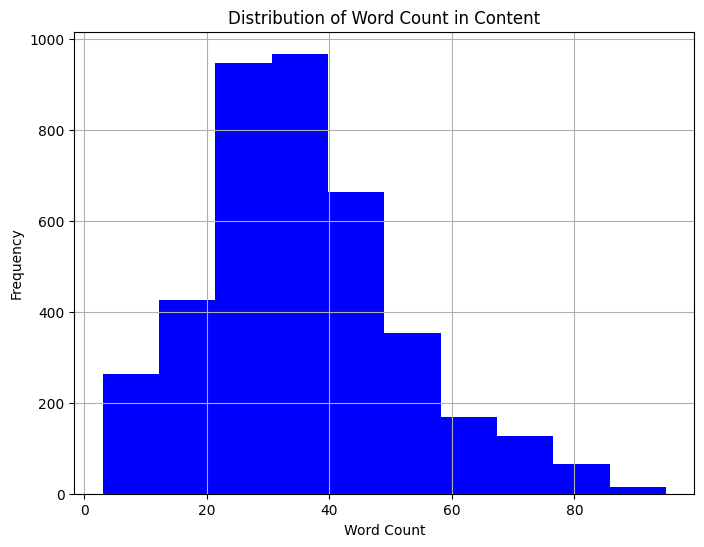

In [72]:
plt.figure(figsize=(8, 6))
plt.hist(data['token_count'], bins=10, color='blue')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.title('Distribution of Word Count in Content')
plt.grid(True)
plt.show()

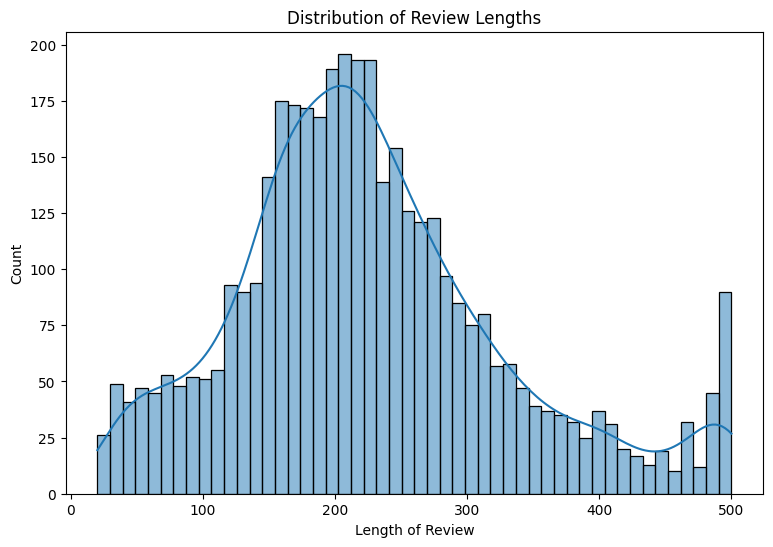

In [73]:
data['Review Length'] = data['content'].apply(len)
plt.figure(figsize=(9, 6))
sns.histplot(data['Review Length'], bins=50, kde=True)
plt.title('Distribution of Review Lengths')
plt.xlabel('Length of Review')
plt.ylabel('Count')
plt.show()

In [76]:
data.duplicated(subset=['content']).sum()

np.int64(0)

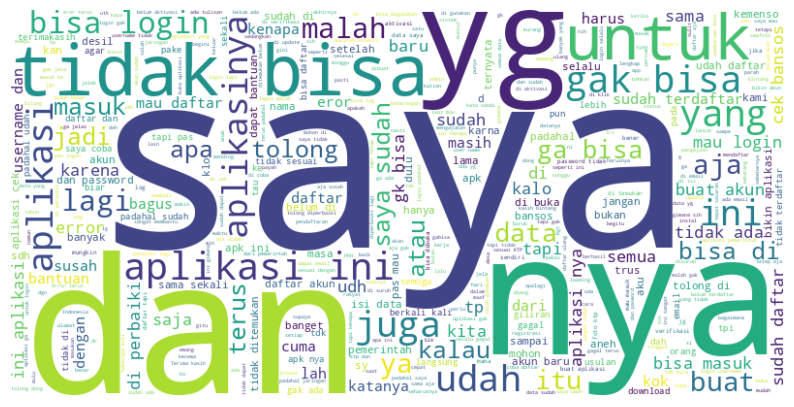

In [77]:
def make_word_cloud(text, max_words=1000):
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        max_words=max_words
    ).generate(text)

    plt.figure(figsize=(10, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.show()

all_words = ' '.join(data['content'].astype(str))
make_word_cloud(all_words, max_words=5000)

#Data Cleaning

In [78]:
data

,reviewId,content,score,at,Tahun,token_count,Review Length
0,c66c2410-377c-4262-84a3-28a297743830,sudah sangat bagus tampilannya hanya sayangnya...,5,2026-05-29 11:10:48,2026,57,390
1,4a489ca2-9de2-43cb-8bbe-07722cd5802b,"aplikasi terburuk sedunia. login gabisa, alasa...",1,2026-05-30 00:35:08,2026,73,454
2,38131a6a-4f73-449e-9866-7719e4d7de1c,"Pas mau pembaruan data ada tulisan ""Terjadi ke...",1,2026-06-06 02:10:43,2026,27,192
3,7519ca42-f25f-4868-9402-4e0a8ee468ed,Tolong dong ini apk yang di upgrade supaya ga ...,2,2026-06-02 02:17:50,2026,47,296
4,4740db48-1ece-40a7-9901-033ffcba0553,1. aplikasi cek bansosnya susah loginnya...uda...,1,2026-05-31 02:08:14,2026,39,258
...,...,...,...,...,...,...,...
3995,14754cc6-f6a6-4b2b-be8f-d3c719034a90,"Sangat buruk sekali, isi from kab ,kec, kel se...",2,2022-10-11 23:51:59,2022,28,161
3996,24eeb0a0-d8a4-46f3-b09d-94f4e0d431f6,Saya mendaftar di aplikasi ini memang benar ha...,3,2022-04-12 12:00:59,2022,34,225
3997,a333448c-5e0c-47f8-b1dd-94b26ebad944,"Aplikasi gk bermutu, di keterangan profil kelu...",1,2023-03-24 01:39:49,2023,29,181
3998,aadd5959-26d2-4427-a538-46a1bbce8dd2,Kenapa ketika saya mau upload photo selfi KTP ...,4,2023-02-22 07:57:03,2023,34,230


In [81]:
import unicodedata
import re
import string
def indonesian_case_folding(s):
    # 1. Normalize Unicode
    s = unicodedata.normalize('NFKD', s)

    # 3. Hapus entitas HTML
    s = re.sub(r'&gt|&lt', ' ', s)

    # 4. Tangani teks dalam kurung (Opsional, dari chat sebelumnya)
    s = re.sub(r'\(.*?\)', ' ', s)

    # 5. PERBAIKAN: Ubah tanda baca menjadi SPASI sebelum dihapus
    # Ini mencegah "banget,kaya" jadi "bangetkaya"
    s = re.sub(f"([{re.escape(string.punctuation)}])", r" \1 ", s)

    # 6. Normalisasi pengulangan huruf (bagusss -> bagus)
    s = re.sub(r'([a-z])\1{2,}', r'\1', s)

    # 7. Normalisasi pengulangan simbol (!!! -> !)
    s = re.sub(r'([\W+])\1{1,}', r'\1', s)

    # List kata dasar yang berakhiran 'nya' agar tidak dipotong
    exceptions = ['tanya', 'hanya', 'punya','nanya', 'biayanya','bertanya']
    pattern_ex = '|'.join(exceptions)
    s = re.sub(r'\b(?!(?:' + pattern_ex + r'))(\w{3,})(nya|di)\b', r'\1 \2', s)

    # 9. Pisahkan angka dan huruf (iphone15 -> iphone 15)
    s = re.sub(r'(?<=[a-z])(?=\d)|(?<=\d)(?=[a-z])', ' ', s)

    # 10. Hapus semua karakter non-ASCII (Emoji, dll)
    s = re.sub(r'[^\x00-\x7F]+', ' ', s)

    # 11. Hapus tanda baca sepenuhnya
    s = s.translate(str.maketrans('', '', string.punctuation))

    # 12. Hapus angka yang berdiri sendiri
    s = re.sub(r'\b\d+\b', ' ', s)

    # 13. FINAL: Gabungkan spasi berlebih
    s = ' '.join(s.split())

    return s.strip()

In [82]:
data["processed_review"] = data['content'].apply(indonesian_case_folding)
data

,reviewId,content,score,at,Tahun,token_count,Review Length,processed_review
0,c66c2410-377c-4262-84a3-28a297743830,sudah sangat bagus tampilannya hanya sayangnya...,5,2026-05-29 11:10:48,2026,57,390,sudah sangat bagus tampilan nya hanya sayang n...
1,4a489ca2-9de2-43cb-8bbe-07722cd5802b,"aplikasi terburuk sedunia. login gabisa, alasa...",1,2026-05-30 00:35:08,2026,73,454,aplikasi terburuk sedunia login gabisa alasan ...
2,38131a6a-4f73-449e-9866-7719e4d7de1c,"Pas mau pembaruan data ada tulisan ""Terjadi ke...",1,2026-06-06 02:10:43,2026,27,192,Pas mau pembaruan data ada tulisan Terja di ke...
3,7519ca42-f25f-4868-9402-4e0a8ee468ed,Tolong dong ini apk yang di upgrade supaya ga ...,2,2026-06-02 02:17:50,2026,47,296,Tolong dong ini apk yang di upgrade supaya ga ...
4,4740db48-1ece-40a7-9901-033ffcba0553,1. aplikasi cek bansosnya susah loginnya...uda...,1,2026-05-31 02:08:14,2026,39,258,aplikasi cek bansos nya susah login nya udah b...
...,...,...,...,...,...,...,...,...
3995,14754cc6-f6a6-4b2b-be8f-d3c719034a90,"Sangat buruk sekali, isi from kab ,kec, kel se...",2,2022-10-11 23:51:59,2022,28,161,Sangat buruk sekali isi from kab kec kel selal...
3996,24eeb0a0-d8a4-46f3-b09d-94f4e0d431f6,Saya mendaftar di aplikasi ini memang benar ha...,3,2022-04-12 12:00:59,2022,34,225,Saya mendaftar di aplikasi ini memang benar ha...
3997,a333448c-5e0c-47f8-b1dd-94b26ebad944,"Aplikasi gk bermutu, di keterangan profil kelu...",1,2023-03-24 01:39:49,2023,29,181,Aplikasi gk bermutu di keterangan profil kelua...
3998,aadd5959-26d2-4427-a538-46a1bbce8dd2,Kenapa ketika saya mau upload photo selfi KTP ...,4,2023-02-22 07:57:03,2023,34,230,Kenapa ketika saya mau upload photo selfi KTP ...


In [83]:
def case_folding(text):
    if isinstance(text, str):
        lowercase_text = text.lower()
        return lowercase_text
    else:
        return text

data['case_folding'] = data['processed_review'].apply(case_folding)
data.head(5)

,reviewId,content,score,at,Tahun,token_count,Review Length,processed_review,case_folding
0,c66c2410-377c-4262-84a3-28a297743830,sudah sangat bagus tampilannya hanya sayangnya...,5,2026-05-29 11:10:48,2026,57,390,sudah sangat bagus tampilan nya hanya sayang n...,sudah sangat bagus tampilan nya hanya sayang n...
1,4a489ca2-9de2-43cb-8bbe-07722cd5802b,"aplikasi terburuk sedunia. login gabisa, alasa...",1,2026-05-30 00:35:08,2026,73,454,aplikasi terburuk sedunia login gabisa alasan ...,aplikasi terburuk sedunia login gabisa alasan ...
2,38131a6a-4f73-449e-9866-7719e4d7de1c,"Pas mau pembaruan data ada tulisan ""Terjadi ke...",1,2026-06-06 02:10:43,2026,27,192,Pas mau pembaruan data ada tulisan Terja di ke...,pas mau pembaruan data ada tulisan terja di ke...
3,7519ca42-f25f-4868-9402-4e0a8ee468ed,Tolong dong ini apk yang di upgrade supaya ga ...,2,2026-06-02 02:17:50,2026,47,296,Tolong dong ini apk yang di upgrade supaya ga ...,tolong dong ini apk yang di upgrade supaya ga ...
4,4740db48-1ece-40a7-9901-033ffcba0553,1. aplikasi cek bansosnya susah loginnya...uda...,1,2026-05-31 02:08:14,2026,39,258,aplikasi cek bansos nya susah login nya udah b...,aplikasi cek bansos nya susah login nya udah b...


In [84]:
data['tokenized_words'] = data['case_folding'].apply(word_tokenize)
data.head()

,reviewId,content,score,at,Tahun,token_count,Review Length,processed_review,case_folding,tokenized_words
0,c66c2410-377c-4262-84a3-28a297743830,sudah sangat bagus tampilannya hanya sayangnya...,5,2026-05-29 11:10:48,2026,57,390,sudah sangat bagus tampilan nya hanya sayang n...,sudah sangat bagus tampilan nya hanya sayang n...,"[sudah, sangat, bagus, tampilan, nya, hanya, s..."
1,4a489ca2-9de2-43cb-8bbe-07722cd5802b,"aplikasi terburuk sedunia. login gabisa, alasa...",1,2026-05-30 00:35:08,2026,73,454,aplikasi terburuk sedunia login gabisa alasan ...,aplikasi terburuk sedunia login gabisa alasan ...,"[aplikasi, terburuk, sedunia, login, gabisa, a..."
2,38131a6a-4f73-449e-9866-7719e4d7de1c,"Pas mau pembaruan data ada tulisan ""Terjadi ke...",1,2026-06-06 02:10:43,2026,27,192,Pas mau pembaruan data ada tulisan Terja di ke...,pas mau pembaruan data ada tulisan terja di ke...,"[pas, mau, pembaruan, data, ada, tulisan, terj..."
3,7519ca42-f25f-4868-9402-4e0a8ee468ed,Tolong dong ini apk yang di upgrade supaya ga ...,2,2026-06-02 02:17:50,2026,47,296,Tolong dong ini apk yang di upgrade supaya ga ...,tolong dong ini apk yang di upgrade supaya ga ...,"[tolong, dong, ini, apk, yang, di, upgrade, su..."
4,4740db48-1ece-40a7-9901-033ffcba0553,1. aplikasi cek bansosnya susah loginnya...uda...,1,2026-05-31 02:08:14,2026,39,258,aplikasi cek bansos nya susah login nya udah b...,aplikasi cek bansos nya susah login nya udah b...,"[aplikasi, cek, bansos, nya, susah, login, nya..."


In [85]:
# first dictionary - "new_kamusalay.csv"
alay_dict = pd.read_csv(
    '/content/new_kamusalay.csv',
    names=['original', 'replacement'],  # Set column names manually
    encoding='latin-1'
)

alay_dict_map = dict(zip(alay_dict['original'], alay_dict['replacement']))

In [86]:
# second dictionary - "combined_slang_words.txt"
with open('/content/combined_slang_words.txt', 'r', encoding='utf-8') as file:
    slang_dict_txt = json.load(file)

In [87]:
# merge both dictionary and function
combined_slang_dict = {**alay_dict_map, **slang_dict_txt}

def normalize_slang(tokens):
    return [combined_slang_dict.get(token, token) for token in tokens]

In [88]:
data['normalization'] = data['tokenized_words'].apply(normalize_slang)

In [89]:
data[['tokenized_words', 'normalization']][data['tokenized_words'] != data['normalization']].sample(20)

,tokenized_words,normalization
2156,"[login, gagal, terus, entah, aplikasi, apaan]","[login, gagal, terus, gatau, aplikasi, apa]"
789,"[bingung, kenapa, yah, pas, mau, di, bagian, u...","[bingung, kenapa, ya, pas, mau, di, bagian, us..."
3597,"[aplikasi, ini, sangat, bermanfaat, bagi, masy...","[aplikasi, ini, sangat, bermanfaat, bagi, masy..."
219,"[duit, buat, bikin, apk, nya, kebanyakan, diko...","[uang, buat, bikin, aplikasi, nya, kebanyakan,..."
2774,"[koneksi, error, alamat, salah, aplikasi, seda...","[koneksi, error, alamat, salah, aplikasi, seda..."
3757,"[saya, ingin, mencoba, masuk, tetapi, sering, ...","[saya, ingin, mencoba, masuk, tetapi, sering, ..."
938,"[pa, maaf, tolong, kalo, buat, aplikasi, tu, d...","[apa, maaf, tolong, kalau, buat, aplikasi, itu..."
1720,"[ini, aplikasi, kenapa, ya, apa, karna, sekran...","[ini, aplikasi, kenapa, iya, apa, karena, seka..."
2337,"[aplikasi, nya, error, trs, saat, buat, akun, ...","[aplikasi, nya, error, terus, saat, buat, akun..."
683,"[apaan, sih, gak, bisa, daftar, terus]","[apa, sih, tidak, bisa, daftar, terus]"


In [90]:
with open("/content/indonesian-words.txt", "r", encoding="utf-8") as file:
    corpus_words = set(line.strip().lower() for line in file)

In [91]:
all_processed_tokens = [
    word
    for tokens in data['normalization']
    if isinstance(tokens, list)
    for word in tokens
]
unique_not_in_corpus = sorted(
    set(word for word in all_processed_tokens if isinstance(word, str)and word not in corpus_words))
print(unique_not_in_corpus)

[' gratis', ' lengkap', ' tanggapan', ' tanpa', ' terbaru', ' zaman', '18x', '25juli', '2d', '4g', '5g', 'Cuma', 'a', 'aasu', 'abalan', 'access', 'actual', 'ada', 'ada kan', 'ada yang', 'adakan', 'adanya', 'adilkah', 'admi', 'admin-nya', 'admind', 'aduh', 'adzim', 'afk', 'agr', 'ah', 'ah sudahlah', 'ai', 'aibon', 'aih', 'aik', 'ain', 'ajari', 'ajuan', 'ajukan', 'akalan', 'akan', 'akibat', 'akibay', 'akir', 'aktifkan', 'aktivasi', 'aktivasi ini', 'aktivasii', 'aktivis', 'aku gagal', 'aku itu', 'aku kasih', 'aku rasa', 'akui', 'akunmu', 'al fatihah', 'ala', 'alah', 'alasannya', 'alesa', 'alias', 'alihkan', 'aliran langsung', 'allahu', 'almarhum', 'almid', 'alokasikan', 'amanah', 'amarah', 'amat', 'amati', 'amatir', 'amatiran', 'amburadul', 'amien', 'ampas', 'amplop', 'ampun', 'ampunan', 'ampunilah', 'amputasi', 'anakku', 'anda', 'andalkan', 'andil', 'android', 'aneh', 'angel', 'anggap', 'anggara', 'anggaran pendapatan dan belanja negara', 'angkutan kota', 'angota', 'anji', 'anjin', 'anji

In [92]:
file_name = "unique_not_in_corpus.txt"
with open(file_name, "w", encoding="utf-8") as f:
    for word in unique_not_in_corpus:
        f.write(word + "\n")

print(f"File {file_name} berhasil dibuat!")

File unique_not_in_corpus.txt berhasil dibuat!


Dari hasil corpus ini akan di cek ulang kembali kata yang typo atau yang perlu di perbaiki akan di tambahkan kembali ke kamus combined_slang_words

In [93]:
data

,reviewId,content,score,at,Tahun,token_count,Review Length,processed_review,case_folding,tokenized_words,normalization
0,c66c2410-377c-4262-84a3-28a297743830,sudah sangat bagus tampilannya hanya sayangnya...,5,2026-05-29 11:10:48,2026,57,390,sudah sangat bagus tampilan nya hanya sayang n...,sudah sangat bagus tampilan nya hanya sayang n...,"[sudah, sangat, bagus, tampilan, nya, hanya, s...","[sudah, sangat, bagus, tampilan, nya, hanya, s..."
1,4a489ca2-9de2-43cb-8bbe-07722cd5802b,"aplikasi terburuk sedunia. login gabisa, alasa...",1,2026-05-30 00:35:08,2026,73,454,aplikasi terburuk sedunia login gabisa alasan ...,aplikasi terburuk sedunia login gabisa alasan ...,"[aplikasi, terburuk, sedunia, login, gabisa, a...","[aplikasi, terburuk, sedunia, login, tidak bis..."
2,38131a6a-4f73-449e-9866-7719e4d7de1c,"Pas mau pembaruan data ada tulisan ""Terjadi ke...",1,2026-06-06 02:10:43,2026,27,192,Pas mau pembaruan data ada tulisan Terja di ke...,pas mau pembaruan data ada tulisan terja di ke...,"[pas, mau, pembaruan, data, ada, tulisan, terj...","[pas, mau, pembaruan, data, ada, tulisan, kerj..."
3,7519ca42-f25f-4868-9402-4e0a8ee468ed,Tolong dong ini apk yang di upgrade supaya ga ...,2,2026-06-02 02:17:50,2026,47,296,Tolong dong ini apk yang di upgrade supaya ga ...,tolong dong ini apk yang di upgrade supaya ga ...,"[tolong, dong, ini, apk, yang, di, upgrade, su...","[tolong, dong, ini, aplikasi, yang, di, perbar..."
4,4740db48-1ece-40a7-9901-033ffcba0553,1. aplikasi cek bansosnya susah loginnya...uda...,1,2026-05-31 02:08:14,2026,39,258,aplikasi cek bansos nya susah login nya udah b...,aplikasi cek bansos nya susah login nya udah b...,"[aplikasi, cek, bansos, nya, susah, login, nya...","[aplikasi, cek, bansos, nya, susah, login, nya..."
...,...,...,...,...,...,...,...,...,...,...,...
3995,14754cc6-f6a6-4b2b-be8f-d3c719034a90,"Sangat buruk sekali, isi from kab ,kec, kel se...",2,2022-10-11 23:51:59,2022,28,161,Sangat buruk sekali isi from kab kec kel selal...,sangat buruk sekali isi from kab kec kel selal...,"[sangat, buruk, sekali, isi, from, kab, kec, k...","[sangat, buruk, sekali, isi, dari, kabupaten, ..."
3996,24eeb0a0-d8a4-46f3-b09d-94f4e0d431f6,Saya mendaftar di aplikasi ini memang benar ha...,3,2022-04-12 12:00:59,2022,34,225,Saya mendaftar di aplikasi ini memang benar ha...,saya mendaftar di aplikasi ini memang benar ha...,"[saya, mendaftar, di, aplikasi, ini, memang, b...","[saya, mendaftar, di, aplikasi, ini, memang, b..."
3997,a333448c-5e0c-47f8-b1dd-94b26ebad944,"Aplikasi gk bermutu, di keterangan profil kelu...",1,2023-03-24 01:39:49,2023,29,181,Aplikasi gk bermutu di keterangan profil kelua...,aplikasi gk bermutu di keterangan profil kelua...,"[aplikasi, gk, bermutu, di, keterangan, profil...","[aplikasi, tidak, bermutu, di, keterangan, pro..."
3998,aadd5959-26d2-4427-a538-46a1bbce8dd2,Kenapa ketika saya mau upload photo selfi KTP ...,4,2023-02-22 07:57:03,2023,34,230,Kenapa ketika saya mau upload photo selfi KTP ...,kenapa ketika saya mau upload photo selfi ktp ...,"[kenapa, ketika, saya, mau, upload, photo, sel...","[kenapa, ketika, saya, mau, unggah, foto, swaf..."


In [102]:
def load_stopwords(path):
    with open(path, "r", encoding="utf-8") as f:
        return set(line.strip() for line in f if line.strip())

In [103]:
STOPWORDS_ID = load_stopwords("/content/combined_stop_words.txt")

In [104]:
def remove_stopwords(word_list, stopwords_set):
    return [w for w in word_list if w not in stopwords_set]
data['after_filtering'] = data['normalization'].apply(
    lambda x: remove_stopwords(x, STOPWORDS_ID)
)
data

,reviewId,content,score,at,Tahun,token_count,Review Length,processed_review,case_folding,tokenized_words,normalization,after_filtering,final_sentence
0,c66c2410-377c-4262-84a3-28a297743830,sudah sangat bagus tampilannya hanya sayangnya...,5,2026-05-29 11:10:48,2026,57,390,sudah sangat bagus tampilan nya hanya sayang n...,sudah sangat bagus tampilan nya hanya sayang n...,"[sudah, sangat, bagus, tampilan, nya, hanya, s...","[sudah, sangat, bagus, tampilan, nya, hanya, s...","[sangat, bagus, tampilan, hanya, sayang, data,...",sangat bagus tampilan nya hanya sayang nya dat...
1,4a489ca2-9de2-43cb-8bbe-07722cd5802b,"aplikasi terburuk sedunia. login gabisa, alasa...",1,2026-05-30 00:35:08,2026,73,454,aplikasi terburuk sedunia login gabisa alasan ...,aplikasi terburuk sedunia login gabisa alasan ...,"[aplikasi, terburuk, sedunia, login, gabisa, a...","[aplikasi, terburuk, sedunia, login, tidak bis...","[aplikasi, terburuk, sedunia, login, tidak bis...",aplikasi terburuk sedunia login tidak bisa ala...
2,38131a6a-4f73-449e-9866-7719e4d7de1c,"Pas mau pembaruan data ada tulisan ""Terjadi ke...",1,2026-06-06 02:10:43,2026,27,192,Pas mau pembaruan data ada tulisan Terja di ke...,pas mau pembaruan data ada tulisan terja di ke...,"[pas, mau, pembaruan, data, ada, tulisan, terj...","[pas, mau, pembaruan, data, ada, tulisan, kerj...","[pas, mau, pembaruan, data, ada, tulisan, kerj...",pas mau pembaruan data ada tulisan kerja kenda...
3,7519ca42-f25f-4868-9402-4e0a8ee468ed,Tolong dong ini apk yang di upgrade supaya ga ...,2,2026-06-02 02:17:50,2026,47,296,Tolong dong ini apk yang di upgrade supaya ga ...,tolong dong ini apk yang di upgrade supaya ga ...,"[tolong, dong, ini, apk, yang, di, upgrade, su...","[tolong, dong, ini, aplikasi, yang, di, perbar...","[tolong, dong, ini, aplikasi, perbarui, supaya...",tolong dong ini aplikasi perbarui supaya tidak...
4,4740db48-1ece-40a7-9901-033ffcba0553,1. aplikasi cek bansosnya susah loginnya...uda...,1,2026-05-31 02:08:14,2026,39,258,aplikasi cek bansos nya susah login nya udah b...,aplikasi cek bansos nya susah login nya udah b...,"[aplikasi, cek, bansos, nya, susah, login, nya...","[aplikasi, cek, bansos, nya, susah, login, nya...","[aplikasi, cek, bansos, susah, login, beberapa...",aplikasi cek bansos nya susah login nya bebera...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,14754cc6-f6a6-4b2b-be8f-d3c719034a90,"Sangat buruk sekali, isi from kab ,kec, kel se...",2,2022-10-11 23:51:59,2022,28,161,Sangat buruk sekali isi from kab kec kel selal...,sangat buruk sekali isi from kab kec kel selal...,"[sangat, buruk, sekali, isi, from, kab, kec, k...","[sangat, buruk, sekali, isi, dari, kabupaten, ...","[sangat, buruk, sekali, isi, kabupaten, kecama...",sangat buruk sekali isi kabupaten kecamatan ke...
3996,24eeb0a0-d8a4-46f3-b09d-94f4e0d431f6,Saya mendaftar di aplikasi ini memang benar ha...,3,2022-04-12 12:00:59,2022,34,225,Saya mendaftar di aplikasi ini memang benar ha...,saya mendaftar di aplikasi ini memang benar ha...,"[saya, mendaftar, di, aplikasi, ini, memang, b...","[saya, mendaftar, di, aplikasi, ini, memang, b...","[mendaftar, aplikasi, ini, memang, benar, habi...",mendaftar aplikasi ini memang benar habis itu ...
3997,a333448c-5e0c-47f8-b1dd-94b26ebad944,"Aplikasi gk bermutu, di keterangan profil kelu...",1,2023-03-24 01:39:49,2023,29,181,Aplikasi gk bermutu di keterangan profil kelua...,aplikasi gk bermutu di keterangan profil kelua...,"[aplikasi, gk, bermutu, di, keterangan, profil...","[aplikasi, tidak, bermutu, di, keterangan, pro...","[aplikasi, tidak, bermutu, keterangan, profil,...",aplikasi tidak bermutu keterangan profil kelua...
3998,aadd5959-26d2-4427-a538-46a1bbce8dd2,Kenapa ketika saya mau upload photo selfi KTP ...,4,2023-02-22 07:57:03,2023,34,230,Kenapa ketika saya mau upload photo selfi KTP ...,kenapa ketika saya mau upload photo selfi ktp ...,"[kenapa, ketika, saya, mau, upload, photo, sel...","[kenapa, ketika, saya, mau, unggah, foto, swaf...","[kenapa, keti

In [105]:
data['final_sentence'] = data['after_filtering'].apply(lambda words: ' '.join(words))
data

,reviewId,content,score,at,Tahun,token_count,Review Length,processed_review,case_folding,tokenized_words,normalization,after_filtering,final_sentence
0,c66c2410-377c-4262-84a3-28a297743830,sudah sangat bagus tampilannya hanya sayangnya...,5,2026-05-29 11:10:48,2026,57,390,sudah sangat bagus tampilan nya hanya sayang n...,sudah sangat bagus tampilan nya hanya sayang n...,"[sudah, sangat, bagus, tampilan, nya, hanya, s...","[sudah, sangat, bagus, tampilan, nya, hanya, s...","[sangat, bagus, tampilan, hanya, sayang, data,...",sangat bagus tampilan hanya sayang data actual...
1,4a489ca2-9de2-43cb-8bbe-07722cd5802b,"aplikasi terburuk sedunia. login gabisa, alasa...",1,2026-05-30 00:35:08,2026,73,454,aplikasi terburuk sedunia login gabisa alasan ...,aplikasi terburuk sedunia login gabisa alasan ...,"[aplikasi, terburuk, sedunia, login, gabisa, a...","[aplikasi, terburuk, sedunia, login, tidak bis...","[aplikasi, terburuk, sedunia, login, tidak bis...",aplikasi terburuk sedunia login tidak bisa ala...
2,38131a6a-4f73-449e-9866-7719e4d7de1c,"Pas mau pembaruan data ada tulisan ""Terjadi ke...",1,2026-06-06 02:10:43,2026,27,192,Pas mau pembaruan data ada tulisan Terja di ke...,pas mau pembaruan data ada tulisan terja di ke...,"[pas, mau, pembaruan, data, ada, tulisan, terj...","[pas, mau, pembaruan, data, ada, tulisan, kerj...","[pas, mau, pembaruan, data, ada, tulisan, kerj...",pas mau pembaruan data ada tulisan kerja kenda...
3,7519ca42-f25f-4868-9402-4e0a8ee468ed,Tolong dong ini apk yang di upgrade supaya ga ...,2,2026-06-02 02:17:50,2026,47,296,Tolong dong ini apk yang di upgrade supaya ga ...,tolong dong ini apk yang di upgrade supaya ga ...,"[tolong, dong, ini, apk, yang, di, upgrade, su...","[tolong, dong, ini, aplikasi, yang, di, perbar...","[tolong, dong, ini, aplikasi, perbarui, supaya...",tolong dong ini aplikasi perbarui supaya tidak...
4,4740db48-1ece-40a7-9901-033ffcba0553,1. aplikasi cek bansosnya susah loginnya...uda...,1,2026-05-31 02:08:14,2026,39,258,aplikasi cek bansos nya susah login nya udah b...,aplikasi cek bansos nya susah login nya udah b...,"[aplikasi, cek, bansos, nya, susah, login, nya...","[aplikasi, cek, bansos, nya, susah, login, nya...","[aplikasi, cek, bansos, susah, login, beberapa...",aplikasi cek bansos susah login beberapa kali ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,14754cc6-f6a6-4b2b-be8f-d3c719034a90,"Sangat buruk sekali, isi from kab ,kec, kel se...",2,2022-10-11 23:51:59,2022,28,161,Sangat buruk sekali isi from kab kec kel selal...,sangat buruk sekali isi from kab kec kel selal...,"[sangat, buruk, sekali, isi, from, kab, kec, k...","[sangat, buruk, sekali, isi, dari, kabupaten, ...","[sangat, buruk, sekali, isi, kabupaten, kecama...",sangat buruk sekali isi kabupaten kecamatan ke...
3996,24eeb0a0-d8a4-46f3-b09d-94f4e0d431f6,Saya mendaftar di aplikasi ini memang benar ha...,3,2022-04-12 12:00:59,2022,34,225,Saya mendaftar di aplikasi ini memang benar ha...,saya mendaftar di aplikasi ini memang benar ha...,"[saya, mendaftar, di, aplikasi, ini, memang, b...","[saya, mendaftar, di, aplikasi, ini, memang, b...","[mendaftar, aplikasi, ini, memang, benar, habi...",mendaftar aplikasi ini memang benar habis itu ...
3997,a333448c-5e0c-47f8-b1dd-94b26ebad944,"Aplikasi gk bermutu, di keterangan profil kelu...",1,2023-03-24 01:39:49,2023,29,181,Aplikasi gk bermutu di keterangan profil kelua...,aplikasi gk bermutu di keterangan profil kelua...,"[aplikasi, gk, bermutu, di, keterangan, profil...","[aplikasi, tidak, bermutu, di, keterangan, pro...","[aplikasi, tidak, bermutu, keterangan, profil,...",aplikasi tidak bermutu keterangan profil kelua...
3998,aadd5959-26d2-4427-a538-46a1bbce8dd2,Kenapa ketika saya mau upload photo selfi KTP ...,4,2023-02-22 07:57:03,2023,34,230,Kenapa ketika saya mau upload photo selfi KTP ...,kenapa ketika saya mau upload photo selfi ktp ...,"[kenapa, ketika, saya, mau, upload, photo, sel...","[kenapa, ketika, saya, mau, unggah, foto, swaf...","[kenapa, keti

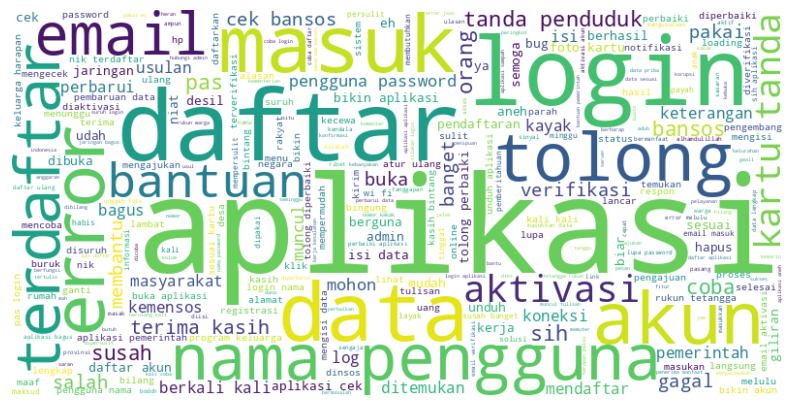

In [107]:
# Load stopwords dari berbagai sumber
with open("/content/combined_stop_words.txt", "r", encoding="utf-8") as f:
    custom_stopwords = set(STOPWORDS)  # Stopwords default dari WordCloud
    custom_stopwords.update(line.strip() for line in f if line.strip())  # Stopwords dari file lokal

# Tambahkan stopwords dari NLTK
stopwords_nltk = set(stopwords.words('indonesian'))
custom_stopwords.update(stopwords_nltk)

def make_word_cloud(text, max_words=1000):
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        stopwords=custom_stopwords,
        max_words=max_words
    ).generate(text)

    plt.figure(figsize=(10, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.show()

all_words = ' '.join(data['final_sentence'])
make_word_cloud(all_words, max_words=800)

#Topic Discovery

In [108]:
data.head()

,reviewId,content,score,at,Tahun,token_count,Review Length,processed_review,case_folding,tokenized_words,normalization,after_filtering,final_sentence
0,c66c2410-377c-4262-84a3-28a297743830,sudah sangat bagus tampilannya hanya sayangnya...,5,2026-05-29 11:10:48,2026,57,390,sudah sangat bagus tampilan nya hanya sayang n...,sudah sangat bagus tampilan nya hanya sayang n...,"[sudah, sangat, bagus, tampilan, nya, hanya, s...","[sudah, sangat, bagus, tampilan, nya, hanya, s...","[sangat, bagus, tampilan, hanya, sayang, data,...",sangat bagus tampilan hanya sayang data actual...
1,4a489ca2-9de2-43cb-8bbe-07722cd5802b,"aplikasi terburuk sedunia. login gabisa, alasa...",1,2026-05-30 00:35:08,2026,73,454,aplikasi terburuk sedunia login gabisa alasan ...,aplikasi terburuk sedunia login gabisa alasan ...,"[aplikasi, terburuk, sedunia, login, gabisa, a...","[aplikasi, terburuk, sedunia, login, tidak bis...","[aplikasi, terburuk, sedunia, login, tidak bis...",aplikasi terburuk sedunia login tidak bisa ala...
2,38131a6a-4f73-449e-9866-7719e4d7de1c,"Pas mau pembaruan data ada tulisan ""Terjadi ke...",1,2026-06-06 02:10:43,2026,27,192,Pas mau pembaruan data ada tulisan Terja di ke...,pas mau pembaruan data ada tulisan terja di ke...,"[pas, mau, pembaruan, data, ada, tulisan, terj...","[pas, mau, pembaruan, data, ada, tulisan, kerj...","[pas, mau, pembaruan, data, ada, tulisan, kerj...",pas mau pembaruan data ada tulisan kerja kenda...
3,7519ca42-f25f-4868-9402-4e0a8ee468ed,Tolong dong ini apk yang di upgrade supaya ga ...,2,2026-06-02 02:17:50,2026,47,296,Tolong dong ini apk yang di upgrade supaya ga ...,tolong dong ini apk yang di upgrade supaya ga ...,"[tolong, dong, ini, apk, yang, di, upgrade, su...","[tolong, dong, ini, aplikasi, yang, di, perbar...","[tolong, dong, ini, aplikasi, perbarui, supaya...",tolong dong ini aplikasi perbarui supaya tidak...
4,4740db48-1ece-40a7-9901-033ffcba0553,1. aplikasi cek bansosnya susah loginnya...uda...,1,2026-05-31 02:08:14,2026,39,258,aplikasi cek bansos nya susah login nya udah b...,aplikasi cek bansos nya susah login nya udah b...,"[aplikasi, cek, bansos, nya, susah, login, nya...","[aplikasi, cek, bansos, nya, susah, login, nya...","[aplikasi, cek, bansos, susah, login, beberapa...",aplikasi cek bansos susah login beberapa kali ...


In [109]:
embedding_model = SentenceTransformer(
    "LazarusNLP/all-indo-e5-small-v4"
)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [110]:
umap_model = UMAP(
    n_neighbors=10,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=42
)

In [111]:
hdbscan_model = hdbscan.HDBSCAN(
    min_cluster_size=10,
    min_samples=5,
    metric="euclidean",
    prediction_data=True
)

In [112]:
topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    nr_topics=None,
    calculate_probabilities=True,
    verbose=True
)

In [113]:
topics, probs = topic_model.fit_transform(
    data["final_sentence"].tolist()
)

2026-06-15 01:34:18,546 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/125 [00:00<?, ?it/s]

2026-06-15 01:37:09,571 - BERTopic - Embedding - Completed ✓
2026-06-15 01:37:09,572 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-06-15 01:37:42,080 - BERTopic - Dimensionality - Completed ✓
2026-06-15 01:37:42,082 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-15 01:37:43,065 - BERTopic - Cluster - Completed ✓
2026-06-15 01:37:43,071 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-06-15 01:37:43,216 - BERTopic - Representation - Completed ✓


In [114]:
data['topic'] = topics
data['topic_probability'] = [max(p) if p is not None else 0 for p in probs]

In [115]:
topic_info = topic_model.get_topic_info()
topic_info

,Topic,Count,Name,Representation,Representative_Docs
0,-1,993,-1_tidak_aplikasi_bisa_ini,"[tidak, aplikasi, bisa, ini, login, data, daft...",[aplikasi apa ini dapat verifikasi lewat email...
1,0,502,0_bansos_cek_aplikasi_ini,"[bansos, cek, aplikasi, ini, ada, dapat, tidak...","[kenapa cek bansos sekarang tidak bisa login, ..."
2,1,225,1_koneksi_jaringan_fi_wi,"[koneksi, jaringan, fi, wi, masalah, bagus, pa...",[aplikasi tidak bisa akses setiap login selalu...
3,2,196,2_penduduk_kartu_tanda_foto,"[penduduk, kartu, tanda, foto, swafoto, sesuai...",[aplikasi tidak jelas ini daftar sesuai petunj...
4,3,171,3_nik_terdaftar_nama_akun,"[nik, terdaftar, nama, akun, daftar, kata, bar...",[aplikasi tidak guna daftar nik ada keterangan...
...,...,...,...,...,...
57,56,11,56_sosial_kementerian_kok_usulan,"[sosial, kementerian, kok, usulan, pergi, suru...",[tolong dong admin error terus kalau mau menga...
58,57,10,57_jelek_kadaluarsa_sana_ruwet,"[jelek, kadaluarsa, sana, ruwet, selalu, amat,...",[aplikasi bagaimana sih setiap mau login lupa ...
59,58,10,58_habiskan_keluar_kuota_buang,"[habiskan, keluar, kuota, buang, daftar, boro,...",[aplikasi apa ini berkali-kali kali daftar tid...
60,59,10,59_toko_main_hapus_afk,"[toko, main, hapus, afk, saja, baik, biar, leb...",[masih banyak kekurangan aplikasi ini bikin ri...


In [116]:
topic_model.visualize_topics()

In [117]:
topic_model.visualize_barchart()

In [118]:
topic_model.visualize_hierarchy()

In [119]:
fig5 = topic_model.visualize_heatmap(n_clusters=9, width=1000, height=1000)
fig5.show()

In [120]:
fig6 = topic_model.visualize_term_rank()
fig6.show()

In [129]:
fig8 = topic_model.visualize_term_rank(log_scale=True)
fig8.show()

In [128]:
fig7 = topic_model.visualize_distribution(probs[25])
fig7.show()

In [137]:
topic_distr, topic_token_distr = topic_model.approximate_distribution(data['final_sentence'], calculate_tokens=True)
df = topic_model.visualize_approximate_distribution(data['final_sentence'].iloc[1], topic_token_distr[1])
df

100%|██████████| 4/4 [00:05<00:00,  1.41s/it]


,aplikasi,terburuk,sedunia,login,tidak,bisa,alasan,koneksi,error,pas,log,in,tiba,tiba,log,out,desil,tidak,muncul,buat,apa,anggaran,buat,aplikasi,besar,tapi,aplikasi,kayak,dibuat,orang,baru,belajar,coding,teks,tanya,jawab,banyak,salah,ketik,masa,sekelas,pemerintah,tidak,mengecek,dulu,sih,masalah,utamanya,tidak,bisa,login,woi,bagaimana,ini,fix,lah,bug,semingguan,tidak,bisa,login,ini,kemana,anggaran,kalian,itu,cuma,menge,fix,saja,masa,tidak,bisa
0_bansos_cek_aplikasi_ini,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.103,0.103,0.103,0.103,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.191,0.191,0.191,0.191,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
1_koneksi_jaringan_fi_wi,0.000,0.000,0.000,0.000,0.267,0.540,0.801,1.091,0.823,0.551,0.289,0.000,0.000,0.000,0.000,0.000,0.000,0.105,0.105,0.105,0.105,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.117,0.117,0.117,0.117,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.161,0.161,0.161,0.161,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
2_penduduk_kartu_tanda_foto,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.131,0.131,0.131,0.131,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
3_nik_terdaftar_nama_akun,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.105,0.205,0.205,0.205,0.100,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.175,0.175,0.175,0.175,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
4_password_pengguna_nama_login,0.000,0.000,0.000,0.103,0.103,0.103,0.103,0.124,0.272,0.397,0.397,0.273,0.125,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.255,0.255,0.255,0.255,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
5_buka_dibuka_bisa_kebuka,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.164,0.164,0.164,0.164,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
6_provinsi_loading_pilih_error,0.000,0.000,0.000,0.000,0.000,0.116,0.239,0.360,0.360,0.244,0.121,0.000,0.000,0.000,0.000,0.000,0.000,0.115,0.115,0.115,0.115,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.104,0.104,0.104,0.104
7_pengguna_login_nama_password,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.107,0.234,0.347,0.347,0.239,0.113,0.000,0.000,0.000,0.000,0.149,0.149,0.149,0.149,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000

#Test Model Topic Discovery

In [135]:
def predict_topic(text, topic_model):
    topic, prob = topic_model.transform([text])

    topic_id = int(topic[0])

    keywords = [
        word
        for word, _
        in topic_model.get_topic(topic_id)[:10]
    ]

    confidence = (
        float(prob[0].max())
        if prob is not None
        else None
    )

    return {
        "text": text,
        "topic_id": topic_id,
        "keywords": keywords,
        "confidence": confidence
    }

In [148]:
text = "Pemerintah Membuat aplikasi yang sering error katanya bansos tapi sistem aja ga jelas"

result = predict_topic(
    text=text,
    topic_model=topic_model
)
df_result = pd.DataFrame([result])
df_result

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

2026-06-15 01:52:02,604 - BERTopic - Dimensionality - Reducing dimensionality of input embeddings.
2026-06-15 01:52:02,637 - BERTopic - Dimensionality - Completed ✓
2026-06-15 01:52:02,638 - BERTopic - Clustering - Approximating new points with `hdbscan_model`
2026-06-15 01:52:02,641 - BERTopic - Probabilities - Start calculation of probabilities with HDBSCAN
2026-06-15 01:52:02,651 - BERTopic - Probabilities - Completed ✓
2026-06-15 01:52:02,652 - BERTopic - Cluster - Completed ✓


,text,topic_id,keywords,confidence
0,Pemerintah Membuat aplikasi yang sering error ...,0,"[bansos, cek, aplikasi, ini, ada, dapat, tidak...",0.999539


#Evaluation Model BERTopic

In [141]:
!pip install gensim
from gensim.corpora import Dictionary
texts = [
    [w for w in doc.split() if w not in STOPWORDS_ID]
    for doc in data["final_sentence"].tolist()
]
dictionary = Dictionary(texts)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 40.4 MB/s eta 0:00:00


In [142]:
topics_words = []
valid_topics = [t for t in set(topics) if t != -1]

for topic in valid_topics:
    topic_words = [
        word for word, _ in topic_model.get_topic(topic)
        if word in dictionary.token2id
    ]
    topics_words.append(topic_words)

In [143]:
topics_words = []
valid_topics = [t for t in set(topics) if t != -1]

for topic in valid_topics:
    words = topic_model.get_topic(topic)

    if words is None:
        continue

    topic_words = [
        word for word, _ in words
        if word in dictionary.token2id
    ]
    if len(topic_words) >= 2:
        topics_words.append(topic_words)

In [144]:
from gensim.models import CoherenceModel

coherence_model = CoherenceModel(
    topics=topics_words,
    texts=texts,
    dictionary=dictionary,
    coherence='c_v'
)

coherence_score = coherence_model.get_coherence()
print(f"Topic Coherence Score (C_v): {coherence_score:.4f}")

Topic Coherence Score (C_v): 0.5460


In [145]:
def calculate_topic_diversity(topic_words):
    all_words = [word for sublist in topic_words for word in sublist]
    unique_words = set(all_words)
    diversity = len(unique_words) / len(all_words)
    return diversity

diversity_score = calculate_topic_diversity(topics_words)
print(f"Topic Diversity Score: {diversity_score:.4f}")

Topic Diversity Score: 0.6222


#Save Model

In [149]:
topic_model.save(
    "bertopic_bansos_model",
    serialization="safetensors",
    save_ctfidf=True,
    save_embedding_model=True
)

In [150]:
import shutil

shutil.make_archive(
    "bertopic_bansos_model",
    "zip",
    "bertopic_bansos_model"
)

'/content/bertopic_bansos_model.zip'

In [151]:
from google.colab import files

files.download("bertopic_bansos_model.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#Requirement

In [155]:
import pandas
import numpy
import nltk
import matplotlib
import seaborn
import plotly
import wordcloud
import sklearn
import sentence_transformers
import bertopic
import umap
import hdbscan
import transformers
import torch
import importlib.metadata

packages = {
    "pandas": pandas.__version__,
    "numpy": numpy.__version__,
    "nltk": nltk.__version__,
    "matplotlib": matplotlib.__version__,
    "seaborn": seaborn.__version__,
    "plotly": plotly.__version__,
    "wordcloud": wordcloud.__version__,
    "scikit-learn": sklearn.__version__,
    "sentence-transformers": sentence_transformers.__version__,
    "bertopic": bertopic.__version__,
    "umap-learn": umap.__version__,
    "hdbscan": importlib.metadata.version('hdbscan'),
    "transformers": transformers.__version__,
    "torch": torch.__version__,
}

for k, v in packages.items():
    print(f"{k}=={v}")

pandas==2.2.2
numpy==2.0.2
nltk==3.9.1
matplotlib==3.10.0
seaborn==0.13.2
plotly==5.24.1
wordcloud==1.9.6
scikit-learn==1.6.1
sentence-transformers==5.5.1
bertopic==0.17.4
umap-learn==0.5.12
hdbscan==0.8.44
transformers==5.10.2
torch==2.11.0+cpu


In [157]:
with open("requirements.txt", "w") as f:
    for k, v in packages.items():
        f.write(f"{k}=={v}\n")

print("requirements.txt berhasil dibuat")

requirements.txt berhasil dibuat


In [158]:
!cat requirements.txt

pandas==2.2.2
numpy==2.0.2
nltk==3.9.1
matplotlib==3.10.0
seaborn==0.13.2
plotly==5.24.1
wordcloud==1.9.6
scikit-learn==1.6.1
sentence-transformers==5.5.1
bertopic==0.17.4
umap-learn==0.5.12
hdbscan==0.8.44
transformers==5.10.2
torch==2.11.0+cpu


In [159]:
from google.colab import files

files.download("requirements.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>